# ASE GT Mesh Exploration with ATEK

**References:**
- ATEK Docs: [ML_task_surface_recon.md](../external/ATEK/docs/ML_task_surface_recon.md)
- ATEK Tool: [ase_mesh_downloader.py](../external/ATEK/tools/ase_mesh_downloader.py)

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional

import trimesh

import torch

# ATEK evaluation utilities
from atek.evaluation.surface_reconstruction.surface_reconstruction_utils import (
    compute_pts_to_mesh_dist,
    point_to_closest_tri_dist,
)


## Configuration

In [4]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / ".data"
MESH_DIR = DATA_DIR / "ase_meshes"
ATEK_ROOT = PROJECT_ROOT / "external" / "ATEK"

# Example ASE scene from our previous exploration
EXAMPLE_SCENE_ID = "0"  # Adjust based on available scenes
EXAMPLE_SCENE_DIR = (
    DATA_DIR / "semidense_samples" / "ase" / "ase_examples" / EXAMPLE_SCENE_ID
)

# Create directories
MESH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")
print(f"Mesh Directory: {MESH_DIR}")
print(f"Example Scene: {EXAMPLE_SCENE_DIR}")
print(f"Scene exists: {EXAMPLE_SCENE_DIR.exists()}")


Project Root: /home/jandu/repos/NBV
Data Directory: /home/jandu/repos/NBV/.data
Mesh Directory: /home/jandu/repos/NBV/.data/ase_meshes
Example Scene: /home/jandu/repos/NBV/.data/semidense_samples/ase/ase_examples/0
Scene exists: True


## Step 2: Load and Explore a Sample Mesh

Let's load one mesh and examine its properties.

In [6]:
# Find available meshes
available_meshes = sorted(MESH_DIR.glob("*.ply"))
assert len(available_meshes) > 0, "No mesh files found in the mesh directory."

print(f"Found {len(available_meshes)} mesh files:")
print(list(map(lambda p: p.name, available_meshes[:5])))


Found 3 mesh files:
['scene_ply_81022.ply', 'scene_ply_81048.ply', 'scene_ply_82832.ply']


In [ ]:
sample_mesh_path = available_meshes[-1]


In [ ]:
mesh = trimesh.load(sample_mesh_path)

print("=" * 60)
print(f"Mesh: {sample_mesh_path.name}")
print("=" * 60)
print(f"Vertices:        {len(mesh.vertices):,}")
print(f"Faces:           {len(mesh.faces):,}")
print(f"Surface area:    {mesh.area:.3f} m²")
print(f"\nBounding box:")
print(f"  Min: {mesh.bounds[0]}")
print(f"  Max: {mesh.bounds[1]}")
print(f"  Size: {mesh.bounds[1] - mesh.bounds[0]} meters")
print(f"\nCenter of mass:  {mesh.center_mass}")
print(f"\nVertex dtype:    {mesh.vertices.dtype}")
print(f"Face dtype:      {mesh.faces.dtype}")
print("=" * 60)


Mesh: scene_ply_82832.ply
Vertices:        3,052,500
Faces:           6,619,451
Surface area:    2207.294 m²

Bounding box:
  Min: [ -9.10948086 -16.84936714  -0.05      ]
  Max: [8.33558369 2.67726088 3.93752623]
  Size: [17.44506454 19.52662802  3.98752623] meters

Center of mass:  [-0.78025952 -7.1525017   1.72418877]

Vertex dtype:    float64
Face dtype:      int64


## Visualize Mesh Statistics

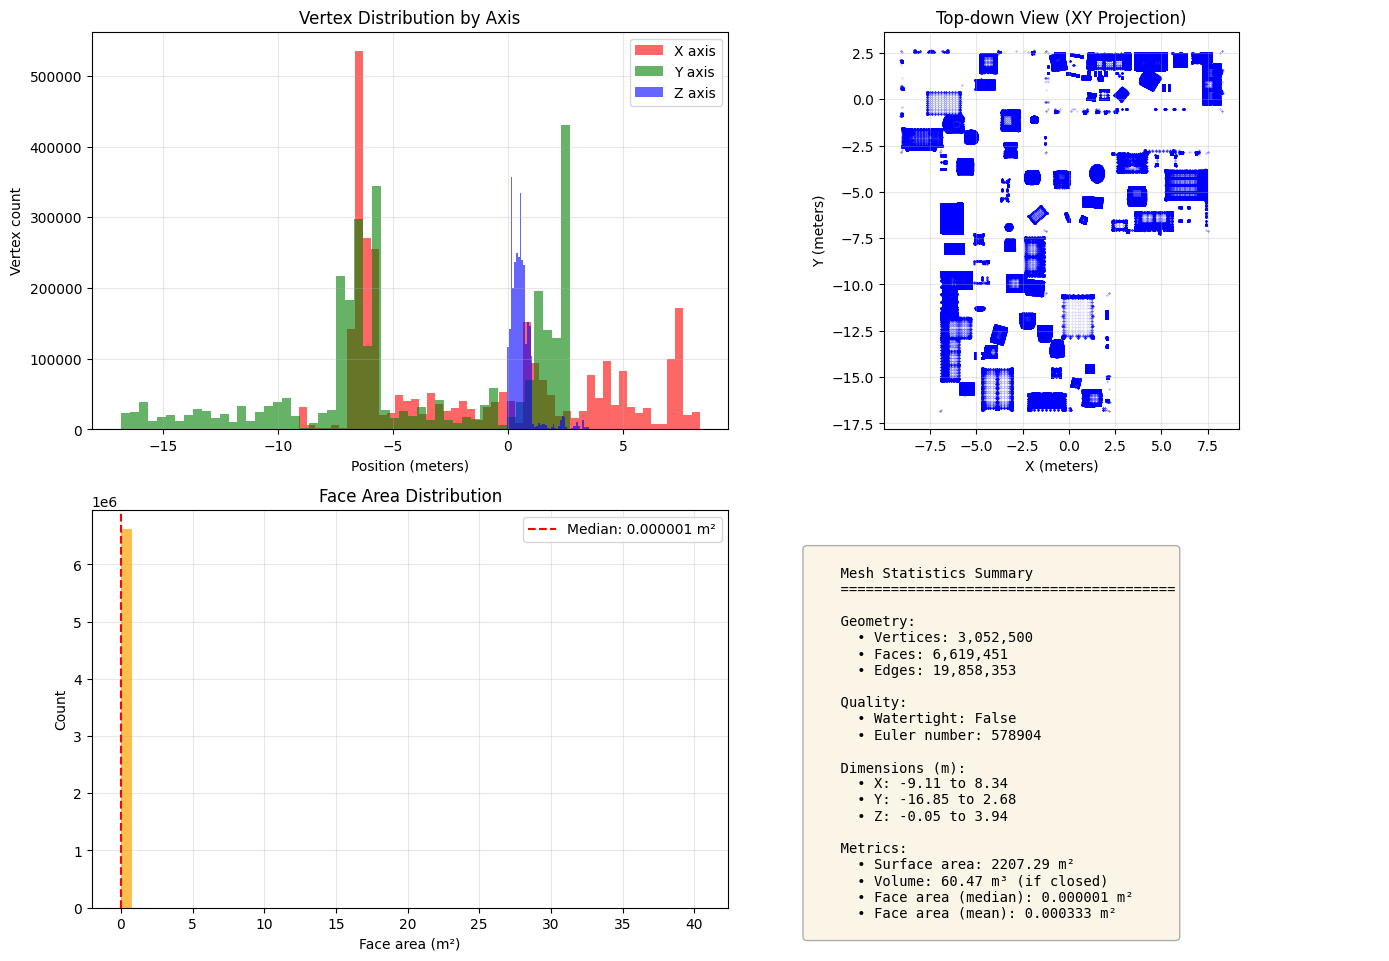


✓ Mesh statistics plotted


In [ ]:
if available_meshes and "mesh" in locals():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Vertex distribution in 3D space
    ax = axes[0, 0]
    vertices = mesh.vertices
    for dim, label, color in zip([0, 1, 2], ["X", "Y", "Z"], ["red", "green", "blue"]):
        ax.hist(
            vertices[:, dim], bins=50, alpha=0.6, label=f"{label} axis", color=color
        )
    ax.set_xlabel("Position (meters)")
    ax.set_ylabel("Vertex count")
    ax.set_title("Vertex Distribution by Axis")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. XY projection (top-down view)
    ax = axes[0, 1]
    ax.scatter(vertices[:, 0], vertices[:, 1], s=0.1, alpha=0.3, c="blue")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.set_title("Top-down View (XY Projection)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    # 3. Face area distribution
    ax = axes[1, 0]
    face_areas = mesh.area_faces
    ax.hist(face_areas, bins=50, color="orange", alpha=0.7)
    ax.set_xlabel("Face area (m²)")
    ax.set_ylabel("Count")
    ax.set_title("Face Area Distribution")
    ax.axvline(
        np.median(face_areas),
        color="red",
        linestyle="--",
        label=f"Median: {np.median(face_areas):.6f} m²",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Summary statistics
    ax = axes[1, 1]
    ax.axis("off")

    stats_text = f"""
    Mesh Statistics Summary
    {"=" * 40}

    Geometry:
      • Vertices: {len(mesh.vertices):,}
      • Faces: {len(mesh.faces):,}
      • Edges: {len(mesh.edges):,}

    Quality:
      • Watertight: {mesh.is_watertight}
      • Euler number: {mesh.euler_number}

    Dimensions (m):
      • X: {mesh.bounds[0][0]:.2f} to {mesh.bounds[1][0]:.2f}
      • Y: {mesh.bounds[0][1]:.2f} to {mesh.bounds[1][1]:.2f}
      • Z: {mesh.bounds[0][2]:.2f} to {mesh.bounds[1][2]:.2f}

    Metrics:
      • Surface area: {mesh.area:.2f} m²
      • Volume: {mesh.volume:.2f} m³ (if closed)
      • Face area (median): {np.median(face_areas):.6f} m²
      • Face area (mean): {np.mean(face_areas):.6f} m²
    """

    ax.text(
        0.1,
        0.9,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3),
    )

    plt.tight_layout()
    plt.show()


## Sample Points from Mesh Surface

Sampling 10,000 points from mesh surface...
✓ Sampled 10,000 points
  Shape: (10000, 3)
  Dtype: float64

Sample statistics:
  Mean: [-0.81798356 -5.53988753  1.65215533]
  Std:  [4.74332805 6.07421325 1.56011521]
  Min:  [ -9.10947994 -16.84936714  -0.05      ]
  Max:  [8.29058361 2.65320232 3.93752623]


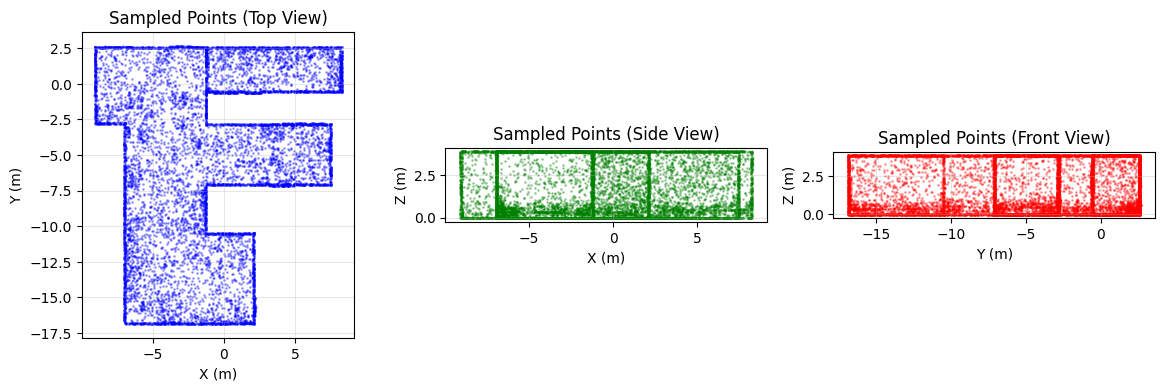

In [ ]:
# Sample points from surface
num_samples = 10000
print(f"Sampling {num_samples:,} points from mesh surface...")

sampled_points, face_indices = trimesh.sample.sample_surface(mesh, num_samples, seed=42)

print(f"✓ Sampled {len(sampled_points):,} points")
print(f"  Shape: {sampled_points.shape}")
print(f"  Dtype: {sampled_points.dtype}")
print(f"\nSample statistics:")
print(f"  Mean: {sampled_points.mean(axis=0)}")
print(f"  Std:  {sampled_points.std(axis=0)}")
print(f"  Min:  {sampled_points.min(axis=0)}")
print(f"  Max:  {sampled_points.max(axis=0)}")

# Visualize sampled points
fig = plt.figure(figsize=(12, 4))

# XY view
ax1 = fig.add_subplot(131)
ax1.scatter(sampled_points[:, 0], sampled_points[:, 1], s=1, alpha=0.3, c="blue")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_title("Sampled Points (Top View)")
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)

# XZ view
ax2 = fig.add_subplot(132)
ax2.scatter(sampled_points[:, 0], sampled_points[:, 2], s=1, alpha=0.3, c="green")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Z (m)")
ax2.set_title("Sampled Points (Side View)")
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)

# YZ view
ax3 = fig.add_subplot(133)
ax3.scatter(sampled_points[:, 1], sampled_points[:, 2], s=1, alpha=0.3, c="red")
ax3.set_xlabel("Y (m)")
ax3.set_ylabel("Z (m)")
ax3.set_title("Sampled Points (Front View)")
ax3.set_aspect("equal")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Compute Distance Between Two Meshes

Demonstrating mesh-to-mesh distance computation...

Mesh 1: scene_ply_81022.ply
Mesh 2: scene_ply_81048.ply

Computing distances from 1000 points to mesh2...


/home/jandu/miniforge3/envs/aria-nbv/lib/python3.11/site-packages/atek/evaluation/surface_reconstruction/surface_reconstruction_utils.py:83: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  n = torch.cross(u, v)



Distance Statistics (mesh1 → mesh2):
  Mean:   5.1186 m
  Median: 3.5477 m
  Min:    0.0000 m
  Max:    14.6279 m
  Std:    4.7004 m


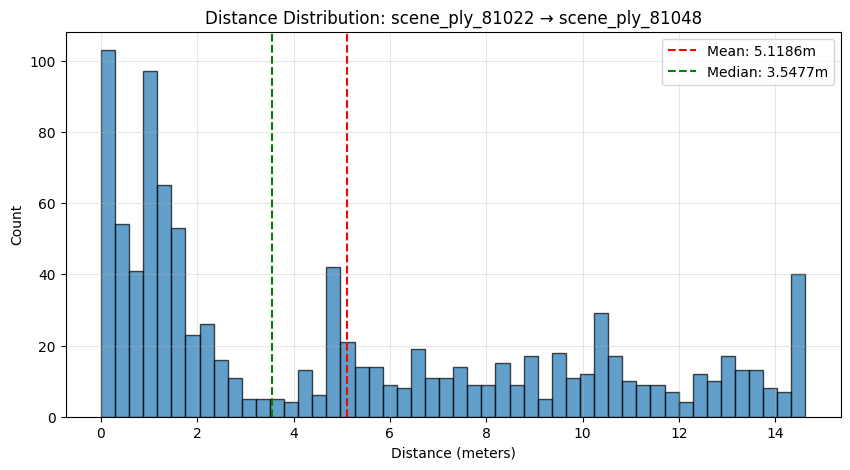

In [17]:
# Load two different meshes
mesh1_path = available_meshes[0]
mesh2_path = available_meshes[1]

print(f"Mesh 1: {mesh1_path.name}")
print(f"Mesh 2: {mesh2_path.name}")

mesh1 = trimesh.load(mesh1_path)
mesh2 = trimesh.load(mesh2_path)

# Sample points from mesh1
points1, _ = trimesh.sample.sample_surface(mesh1, 1000, seed=42)


points_tensor = torch.from_numpy(points1).float()
mesh2_vertices = torch.from_numpy(mesh2.vertices.view(np.ndarray)).float()
mesh2_faces = torch.from_numpy(mesh2.faces.view(np.ndarray)).long()

print(f"\nComputing distances from {len(points1)} points to mesh2...")
distances = compute_pts_to_mesh_dist(
    points_tensor, mesh2_faces, mesh2_vertices, step=50000
)

print(f"\nDistance Statistics (mesh1 → mesh2):")
print(f"  Mean:   {distances.mean():.4f} m")
print(f"  Median: {np.median(distances):.4f} m")
print(f"  Min:    {distances.min():.4f} m")
print(f"  Max:    {distances.max():.4f} m")
print(f"  Std:    {distances.std():.4f} m")

# Plot distance distribution
plt.figure(figsize=(10, 5))
plt.hist(distances, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Distance (meters)")
plt.ylabel("Count")
plt.title(f"Distance Distribution: {mesh1_path.stem} → {mesh2_path.stem}")
plt.axvline(
    distances.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {distances.mean():.4f}m",
)
plt.axvline(
    np.median(distances),
    color="green",
    linestyle="--",
    label=f"Median: {np.median(distances):.4f}m",
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Load two different meshes
mesh1_path = available_meshes[0]
mesh2_path = available_meshes[1]

print(f"Mesh 1: {mesh1_path.name}")
print(f"Mesh 2: {mesh2_path.name}")

mesh1 = trimesh.load(mesh1_path)
mesh2 = trimesh.load(mesh2_path)

# Sample points from mesh1
points1, _ = trimesh.sample.sample_surface(mesh1, 1000, seed=42)


points_tensor = torch.from_numpy(points1).float().cuda()
mesh2_vertices = torch.from_numpy(mesh2.vertices.view(np.ndarray)).float().cuda()
mesh2_faces = torch.from_numpy(mesh2.faces.view(np.ndarray)).long().cuda()

print(f"\nComputing distances from {len(points1)} points to mesh2...")
distances = compute_pts_to_mesh_dist(
    points_tensor, mesh2_faces, mesh2_vertices, step=50000
)


print(f"\nDistance Statistics (mesh1 -> mesh2):")
print(f"  Mean:   {distances.mean():.4f} m")
print(f"  Median: {np.median(distances):.4f} m")
print(f"  Min:    {distances.min():.4f} m")
print(f"  Max:    {distances.max():.4f} m")
print(f"  Std:    {distances.std():.4f} m")


Mesh 1: scene_ply_81022.ply
Mesh 2: scene_ply_81048.ply

Computing distances from 1000 points to mesh2...

Distance Statistics (mesh1 → mesh2):
  Mean:   5.1186 m
  Median: 3.5477 m
  Min:    0.0000 m
  Max:    14.6279 m
  Std:    4.7004 m


### Performance Analysis

- `compute_pts_to_mesh_dist` took 3m 21s on CPU and 5.5s on GPU for 1000 points

# Mesh Quality Analysis

Analyze mesh properties relevant to Next-Best-View planning.

In [ ]:
print("=" * 60)

print(f"\n1. Watertight: {mesh.is_watertight}")

edge_lengths = np.linalg.norm(
    mesh.vertices[mesh.edges[:, 0]] - mesh.vertices[mesh.edges[:, 1]], axis=1
)
avg_edge_length = edge_lengths.mean()
print(f"\n2. Mesh Resolution:")
print(
    f"   Average edge length: {avg_edge_length:.4f} m ({avg_edge_length * 100:.2f} cm)"
)
print(f"   Min edge length: {edge_lengths.min():.4f} m")
print(f"   Max edge length: {edge_lengths.max():.4f} m")

# 3. Surface complexity
vertex_density = len(mesh.vertices) / mesh.area
print(f"\n3. Surface Complexity:")
print(f"   Vertex density: {vertex_density:.2f} vertices/m²")
print(f"   Face density: {len(mesh.faces) / mesh.area:.2f} faces/m²")

# 4. Bounding box and scene size
bbox_size = mesh.bounds[1] - mesh.bounds[0]
print(f"\n4. Scene Dimensions:")
print(f"   Width (X):  {bbox_size[0]:.2f} m")
print(f"   Depth (Y):  {bbox_size[1]:.2f} m")
print(f"   Height (Z): {bbox_size[2]:.2f} m")
print(f"   Diagonal:   {np.linalg.norm(bbox_size):.2f} m")

# 5. Implications for NBV
print(f"\n5. Implications for NBV Research:")
print(f"   + Resolution ({avg_edge_length * 100:.1f}cm edges) determines:")
print(f"     - Minimum viewpoint spacing for new information")
print(f"     - Reconstruction quality we can expect")
print(f"   + Scene size ({bbox_size[0]:.1f}x{bbox_size[1]:.1f}m) affects:")
print(f"     - Camera placement strategy")
print(f"     - Number of views needed for coverage")
print(f"   + Vertex density ({vertex_density:.0f} verts/m²) indicates:")
print(f"     - Ground truth detail level")
print(f"     - Target reconstruction fidelity")

print("\n" + "=" * 60)


Mesh Quality Analysis for NBV Research

1. Watertight: False

2. Mesh Resolution:
   Average edge length: 0.0106 m (1.06 cm)
   Min edge length: 0.0000 m
   Max edge length: 14.5618 m

3. Surface Complexity:
   Vertex density: 1382.92 vertices/m²
   Face density: 2998.90 faces/m²

4. Scene Dimensions:
   Width (X):  17.45 m
   Depth (Y):  19.53 m
   Height (Z): 3.99 m
   Diagonal:   26.49 m

5. Implications for NBV Research:
   + Resolution (1.1cm edges) determines:
     - Minimum viewpoint spacing for new information
     - Reconstruction quality we can expect
   + Scene size (17.4x19.5m) affects:
     - Camera placement strategy
     - Number of views needed for coverage
   + Vertex density (1383 verts/m²) indicates:
     - Ground truth detail level
     - Target reconstruction fidelity



### Useful Commands

```bash
# Download ASE meshes
python3 external/ATEK/tools/ase_mesh_downloader.py \
  --input-json-path ase_mesh_download_urls.json \
  --output-folder-path .data/ase_meshes

# Evaluate surface reconstruction
python3 external/ATEK/tools/benchmarking_surface_reconstruction.py \
  --input-folder results/ \
  --pred-mesh pred_mesh.ply \
  --gt-mesh gt_mesh.ply \
  --output-file metrics.json
```